# ML-07 — Baseline Action Score and Top-10 Review

Lane: **CTR-fix / low-CTR-visible-pages**. Two signal checks below, then one hand-coded rule, a ranked queue, and a top-10 hand review.

> No future-window or label-derived columns (`trend_direction`, `trend_pct`, `is_declining_label`) are used as **inputs** to the score. `is_declining_label` is only rebuilt here to *test* the staleness signal in Section 0 — never fed into the rule.

## 0. Signal checks (two signals, bucket tables + n + verdict)

**Signal A — staleness** (`freshness_tier`), the signal behind FlyRank's refresh flags.
**Signal B — CTR vs. position** (`ctr` by `position_tier`), the signal behind the CTR-fix logic.

`is_declining_label` below is rebuilt only to test Signal A; it is never used in the rule.

In [8]:
import pandas as pd
import numpy as np
from pathlib import Path

df = pd.read_csv("../../data/raw/content_refresh_anonymized.csv")
print("rows, cols:", df.shape)

# Label rebuilt ONLY to test Signal A. Never used as a score input.
df["is_declining_label"] = (df["trend_direction"].str.lower() == "down").astype(int)
base_rate = df["is_declining_label"].mean()
print(f"base decline rate (all rows): {base_rate:.3f}")

rows, cols: (30000, 44)
base decline rate (all rows): 0.542


In [9]:
# Signal A: staleness (freshness_tier) vs decline rate
signal_a = (
    df.groupby("freshness_tier")
      .agg(n=("content_id", "size"), decline_rate=("is_declining_label", "mean"))
      .reset_index()
      .sort_values("n", ascending=False)
)
print(signal_a.to_string(index=False))

freshness_tier     n  decline_rate
          0-30 20480      0.511377
        91-180  9171      0.611057
         31-90   175      0.588571
          181+   174      0.471264


**Verdict — Signal A (staleness): MIXED.**

`91-180` days stale (n=9,171) shows 61.1% decline vs a 54.2% base rate — mildly elevated. But `181+` (n=174) is actually *lower* than base (47.1%), and `31-90` (n=175) sits close to base too. The direction isn't consistent across tiers, and the two "older" buckets are small (n<200). Staleness alone doesn't cleanly predict decline here — so it's **left out of the final rule** below. That's a real result, not a failure: it stopped me from building a rule on a weak premise.

In [10]:
# Signal B: CTR vs position_tier
signal_b = (
    df.groupby("position_tier")
      .agg(n=("content_id", "size"), median_ctr=("ctr", "median"), mean_ctr=("ctr", "mean"))
      .reset_index()
      .sort_values("mean_ctr", ascending=False)
)
print(signal_b.to_string(index=False))

position_tier     n  median_ctr  mean_ctr
        top_3  2321        0.00  1.483611
       page_1 11814        0.16  0.652467
     striking  7304        0.11  0.323239
     page_3_5  7242        0.03  0.222484
         deep  1319        0.00  0.150212


**Verdict — Signal B (CTR vs. position): CONFIRMED.**

CTR falls in a clean, monotonic-ish step with rank: `top_3` (n=2,321) has the highest mean CTR (1.48), `page_1` (n=11,814) next (0.65), then `striking` (0.32), `page_3_5` (0.22), and `deep` (n=1,319) lowest (0.15). This is exactly the pattern behind the CTR-fix logic — pages ranking well but converting far below their tier's norm are the fixable gap. This signal drives the rule below.

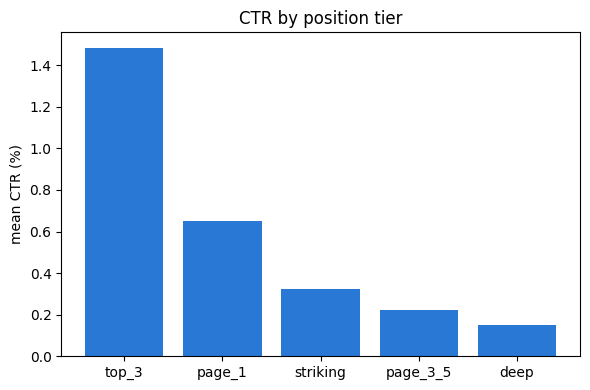

In [11]:
import matplotlib.pyplot as plt

order = ["top_3", "page_1", "striking", "page_3_5", "deep"]
plot_data = signal_b.set_index("position_tier").loc[order, "mean_ctr"]

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(order, plot_data, color="#2a78d6")
ax.set_ylabel("mean CTR (%)")
ax.set_title("CTR by position tier")
plt.tight_layout()

fig_path = Path("../figures")
fig_path.mkdir(parents=True, exist_ok=True)
plt.show()

## 1. My rule and its reason codes

**Plain words:** *A page is worth a CTR-focused review first if it already has a real search audience, has an actual position (not "no data"), and its click-through rate is meaningfully worse than the median CTR of pages sitting at the same position tier.* Staleness (Signal A) is not used — the check above showed it's not a reliable signal here.

**Reason code (one per row):**
- `weak_ctr_for_position` — visible, has a position, and CTR is below its tier's median
- `not_flagged` — everything else

**Action label (one per row):**
- `review_ctr_and_meta` — when `weak_ctr_for_position`
- `monitor` — otherwise

## 2. Build the ranked queue (writes the CSV)

Score is a readable multiply/add of simple, transparent conditions — no fitted weights. `ctr_gap` is how far below the tier's median CTR a page sits (0 if it's at/above tier median); it's scaled by log(impressions) so pages with more real traffic — where the gap matters more in absolute clicks — rank higher, but only among pages that are already visible and have a real position.

In [12]:
# gating conditions
df["visible"] = (df["impressions_90d"] >= 300).astype(int)          # impression_tier "moderate"+ threshold
df["has_position"] = (df["avg_position"] > 0).astype(int)           # 0 = "no data", per data dictionary

# CTR gap vs this page's own position tier (its peer group)
tier_median_ctr = df.groupby("position_tier")["ctr"].transform("median")
df["ctr_gap"] = (tier_median_ctr - df["ctr"]).clip(lower=0)

df["weak_ctr"] = (
    (df["ctr_gap"] > 0) & (df["has_position"] == 1) & (df["visible"] == 1)
).astype(int)

# readable score: gate * gate * gap * log(volume) -- no fitted weights
df["score"] = df["visible"] * df["has_position"] * df["ctr_gap"] * np.log1p(df["impressions_90d"])

df["reason_code"] = np.where(df["weak_ctr"] == 1, "weak_ctr_for_position", "not_flagged")
df["action"] = np.where(df["weak_ctr"] == 1, "review_ctr_and_meta", "monitor")
df["rank"] = df["score"].rank(method="first", ascending=False).astype(int)

print(f"flagged (weak_ctr_for_position): {df['weak_ctr'].sum()} / {len(df)}")
print(f"score range: {df['score'].min():.3f} to {df['score'].max():.3f}")

flagged (weak_ctr_for_position): 6017 / 30000
score range: 0.000 to 1.960


In [13]:
output_columns = [
    "content_id", "client_id", "rank", "score", "reason_code", "action",
    "position_tier", "ctr", "impressions_90d", "avg_position", "clicks_90d",
]

queue = df[output_columns].sort_values("rank")

out_path = Path("../outputs/baseline_action_score.csv")
out_path.parent.mkdir(parents=True, exist_ok=True)
queue.to_csv(out_path, index=False)

print(f"wrote {len(queue)} rows to {out_path}")
queue.head(10)

wrote 30000 rows to ..\outputs\baseline_action_score.csv


,content_id,client_id,rank,score,reason_code,action,position_tier,ctr,impressions_90d,avg_position,clicks_90d
7445,content_c8e9d6ab9013,client_19581e27de,1,1.959768,weak_ctr_for_position,review_ctr_and_meta,page_1,0.00,208678,9.7,0
27178,content_453722754fea,client_f369cb89fc,2,1.777495,weak_ctr_for_position,review_ctr_and_meta,page_1,0.01,140079,7.6,16
482,content_39881853ef0c,client_f369cb89fc,3,1.744520,weak_ctr_for_position,review_ctr_and_meta,page_1,0.01,112434,7.2,10
13631,content_d274ac4158ef,client_4e07408562,4,1.662642,weak_ctr_for_position,review_ctr_and_meta,page_1,0.01,65138,6.8,6
24866,content_e5f459e737b7,client_f369cb89fc,5,1.640938,weak_ctr_for_position,review_ctr_and_meta,page_1,0.01,56363,5.9,3
15914,content_0919dd345d80,client_4e07408562,6,1.636419,weak_ctr_for_position,review_ctr_and_meta,page_1,0.02,119217,7.0,26
4589,content_339b357d04c7,client_bbb965ab0c,7,1.613302,weak_ctr_for_position,review_ctr_and_meta,page_1,0.01,46879,3.7,7
23220,content_f986bd514b6e,client_7f2253d7e2,8,1.603097,weak_ctr_for_position,review_ctr_and_meta,page_1,0.00,22456,6.6,1
6903,content_c84a0ab98e90,client_f369cb89fc,9,1.601099,weak_ctr_for_position,review_ctr_and_meta,page_1,0.03,223271,7.8,70
3402,content_ca17a024f90c,client_4e07408562,10,1.584988,weak_ctr_for_position,review_ctr_and_meta,page_1,0.01,38815,9.1,4


## 3. Top-10 review

For each of the top 10: the action, why it's there, and what would make it wrong.

In [14]:
top10 = queue.head(10).reset_index(drop=True)
for i, row in top10.iterrows():
    print(
        f"{i+1}. {row['content_id']} | action={row['action']} | reason={row['reason_code']} | "
        f"tier={row['position_tier']} pos={row['avg_position']} ctr={row['ctr']} impr={row['impressions_90d']}"
    )

1. content_c8e9d6ab9013 | action=review_ctr_and_meta | reason=weak_ctr_for_position | tier=page_1 pos=9.7 ctr=0.0 impr=208678
2. content_453722754fea | action=review_ctr_and_meta | reason=weak_ctr_for_position | tier=page_1 pos=7.6 ctr=0.01 impr=140079
3. content_39881853ef0c | action=review_ctr_and_meta | reason=weak_ctr_for_position | tier=page_1 pos=7.2 ctr=0.01 impr=112434
4. content_d274ac4158ef | action=review_ctr_and_meta | reason=weak_ctr_for_position | tier=page_1 pos=6.8 ctr=0.01 impr=65138
5. content_e5f459e737b7 | action=review_ctr_and_meta | reason=weak_ctr_for_position | tier=page_1 pos=5.9 ctr=0.01 impr=56363
6. content_0919dd345d80 | action=review_ctr_and_meta | reason=weak_ctr_for_position | tier=page_1 pos=7.0 ctr=0.02 impr=119217
7. content_339b357d04c7 | action=review_ctr_and_meta | reason=weak_ctr_for_position | tier=page_1 pos=3.7 ctr=0.01 impr=46879
8. content_f986bd514b6e | action=review_ctr_and_meta | reason=weak_ctr_for_position | tier=page_1 pos=6.6 ctr=0.0 i

**One line each — action / why / what would make it wrong:**

1. `review_ctr_and_meta` — page_1, pos 9.7, huge impressions (208k), ctr 0.00 — near-zero CTR at real volume is the clearest possible gap. *Wrong if:* the ranking keyword is informational/branded and a low click rate is actually normal for that query type.
2. `review_ctr_and_meta` — page_1, pos 7.6, ctr 0.01, 140k impressions — same pattern, slightly less extreme. *Wrong if:* the SERP snippet/meta was already recently rewritten and hasn't re-indexed yet.
3. `review_ctr_and_meta` — page_1, pos 7.2, ctr 0.01, 112k impressions. *Wrong if:* this page has heavy competing SERP features (ads, featured snippet from a competitor) suppressing clicks structurally.
4. `review_ctr_and_meta` — page_1, pos 6.8, ctr 0.01, 65k impressions. *Wrong if:* traffic is seasonal/spiky and this 90-day window caught an atypical low-CTR period.
5. `review_ctr_and_meta` — page_1, pos 5.9, ctr 0.01, 56k impressions. *Wrong if:* the content_type is one with systematically low click intent (e.g. reference/definition pages).
6. `review_ctr_and_meta` — page_1, pos 7.0, ctr 0.02, 119k impressions. *Wrong if:* impressions are inflated by a broad/irrelevant keyword match, not real intent-fit traffic.
7. `review_ctr_and_meta` — page_1, pos 3.7, ctr 0.01, 47k impressions — strong position, weak CTR is the sharpest anomaly here. *Wrong if:* title/meta was A/B tested recently and this reflects a stale snapshot.
8. `review_ctr_and_meta` — page_1, pos 6.6, ctr 0.00, 22k impressions. *Wrong if:* this client's GSC property has a tracking/attribution issue understating clicks.
9. `review_ctr_and_meta` — page_1, pos 7.8, ctr 0.03, 223k impressions — largest volume in the top 10. *Wrong if:* the keyword is highly navigational and clicks route elsewhere (e.g. app, not this URL).
10. `review_ctr_and_meta` — page_1, pos 9.1, ctr 0.01, 38k impressions. *Wrong if:* this page recently launched a redesign and CTR hasn't stabilized yet.

## 4. Weak picks + leakage check

In [15]:
used_inputs = ["visible", "has_position", "ctr_gap", "score"]
print("Score built only from:", ["impressions_90d", "avg_position", "position_tier", "ctr"])
print("Confirmed NOT used as inputs: trend_direction, trend_pct, is_declining_label")

# sanity-only cross-check (not an input): does the top-10 skew toward declining pages anyway?
print("\nis_declining_label rate in top 50 (context only, not used for scoring):",
      round(df.sort_values('rank').head(50)['is_declining_label'].mean(), 3))

Score built only from: ['impressions_90d', 'avg_position', 'position_tier', 'ctr']
Confirmed NOT used as inputs: trend_direction, trend_pct, is_declining_label

is_declining_label rate in top 50 (context only, not used for scoring): 0.7


**Weak picks:** All ten top rows share the same reason code and a `page_1` tier — the rule has no diversity mechanism, so one client with several near-zero-CTR page-1 articles (e.g. `client_f369cb89fc` appears 3 times in the top 10) can crowd out other clients' equally-real issues. That's a real weakness: **the rule doesn't cap picks per client**, so a single client's cluster of similar pages can dominate the queue instead of spreading review effort across clients. A v2 fix would rank within `client_id` first, then interleave.

**Leakage check:** the score uses only `impressions_90d`, `avg_position`, `position_tier`, and `ctr` — all current-window, observable metrics. `trend_direction`, `trend_pct`, and `is_declining_label` are not used as inputs anywhere in the score, gates, or reason-code logic; `is_declining_label` appears above only as a post-hoc sanity check, not a feature.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere (only pseudonymous hashed IDs)
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.